<a href="https://colab.research.google.com/github/sreelakshmi1405/Internship/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
ds = pd.read_csv('Social_Network_Ads.csv')
X = ds.iloc[:,:-1].values
y = ds.iloc[:,-1].values

In [5]:
ds

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [7]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

**Decision Tree**

In [8]:
from sklearn.tree import DecisionTreeClassifier
classifier_dt = DecisionTreeClassifier(criterion='entropy',random_state=0)
classifier_dt.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [9]:
y_pred_dt = classifier_dt.predict(X_test)

#predict
print(classifier_dt.predict(sc.transform([[30,87000]])))

[0]


In [10]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Accuracy: ",accuracy_score(y_test,y_pred_dt))
print("\nConfusion Matrix: \n",confusion_matrix(y_test,y_pred_dt))
print("\nClassification Report: \n",classification_report(y_test,y_pred_dt))

Accuracy:  0.9

Confusion Matrix: 
 [[53  5]
 [ 3 19]]

Classification Report: 
               precision    recall  f1-score   support

           0       0.95      0.91      0.93        58
           1       0.79      0.86      0.83        22

    accuracy                           0.90        80
   macro avg       0.87      0.89      0.88        80
weighted avg       0.90      0.90      0.90        80



In [11]:
a = input("Enter age: ")
b = input("Enter salary: ")
result = classifier_dt.predict(sc.transform([[a,b]]))

if result == 1:
    print("Will buy")
else:
    print("Will not buy")

Enter age: 50
Enter salary: 80000
Will not buy


**SVM**

In [12]:
from sklearn.svm import SVC
classifier_svm = SVC(kernel='rbf',random_state=0)
classifier_svm.fit(X_train,y_train)

SVC(random_state=0)

In [13]:
y_pred_svm = classifier_svm.predict(X_test)

#predict
print(classifier_svm.predict(sc.transform([[30,87000]])))

[0]


In [14]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Accuracy: ",accuracy_score(y_test,y_pred_svm))
print("\nConfusion Matrix: \n",confusion_matrix(y_test,y_pred_svm))
print("\nClassification Report: \n",classification_report(y_test,y_pred_svm))

Accuracy:  0.95

Confusion Matrix: 
 [[55  3]
 [ 1 21]]

Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        58
           1       0.88      0.95      0.91        22

    accuracy                           0.95        80
   macro avg       0.93      0.95      0.94        80
weighted avg       0.95      0.95      0.95        80



In [15]:
a = input("Enter age: ")
b = input("Enter salary: ")
result = classifier_svm.predict(sc.transform([[a,b]]))

if result == 1:
    print("Will buy")
else:
    print("Will not buy")

Enter age: 50
Enter salary: 80000
Will buy


Visualization of Decision Tree

In [17]:
from sklearn import tree
import matplotlib.pyplot as plt

def plot_decision_tree(classifier_dt, feature_names, class_names):
    plt.figure(figsize=(15, 10))
    tree.plot_tree(classifier_dt,
                   filled=True,
                   feature_names=feature_names,
                   class_names=class_names,
                   rounded=True)
    plt.show()

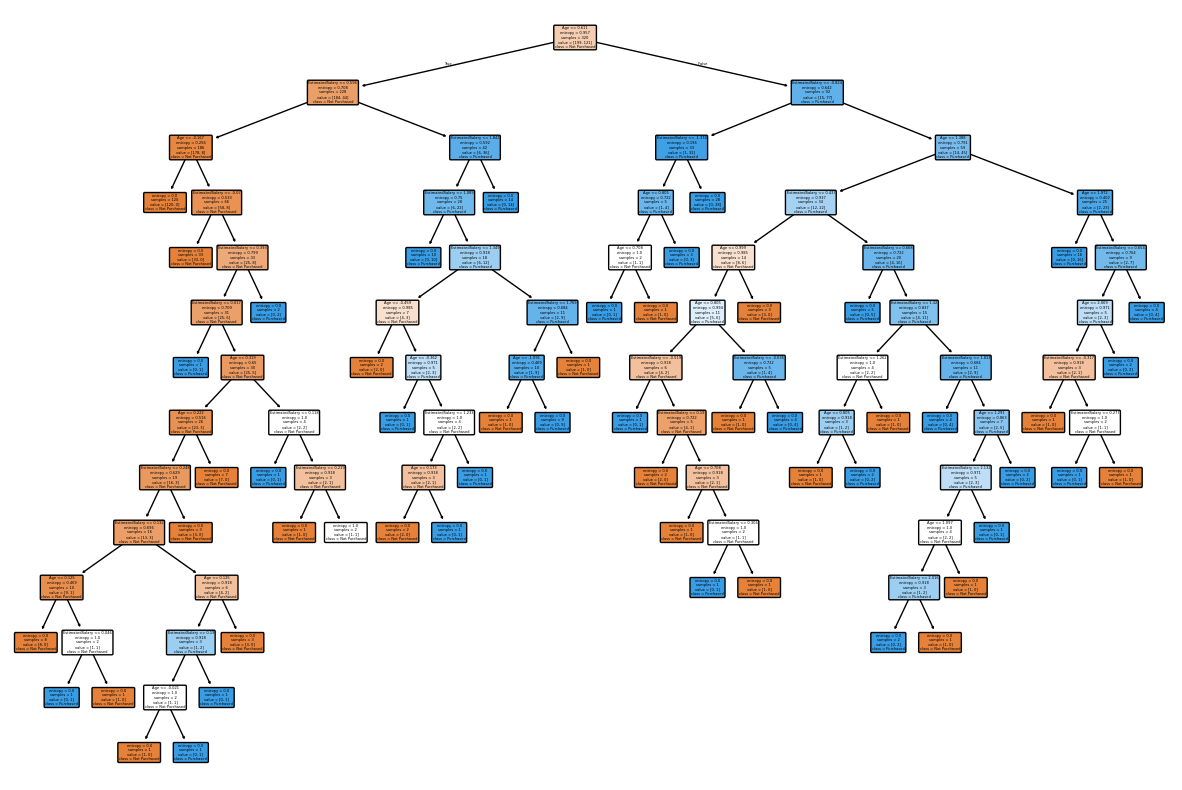

In [18]:
plot_decision_tree(classifier_dt, ['Age', 'EstimatedSalary'], ['Not Purchased', 'Purchased'])

In [23]:
importances = classifier_dt.feature_importances_
print("Feature Importance:")
for name, importance in zip(['Age','EstimatedSalary'], importances):
  print(f"{name}:{importance:.4f}")

Feature Importance:
Age:0.4727
EstimatedSalary:0.5273


Decision Tree with Depth 3

In [19]:
clf = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [21]:
y_pred_dt1 = clf.predict(X_test)
print(clf.predict(sc.transform([[30,87000]])))

[0]


In [22]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Accuracy: ",accuracy_score(y_test,y_pred_dt1))
print("\nConfusion Matrix: \n",confusion_matrix(y_test,y_pred_dt1))
print("\nClassification Report: \n",classification_report(y_test,y_pred_dt1))

Accuracy:  0.95

Confusion Matrix: 
 [[55  3]
 [ 1 21]]

Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        58
           1       0.88      0.95      0.91        22

    accuracy                           0.95        80
   macro avg       0.93      0.95      0.94        80
weighted avg       0.95      0.95      0.95        80



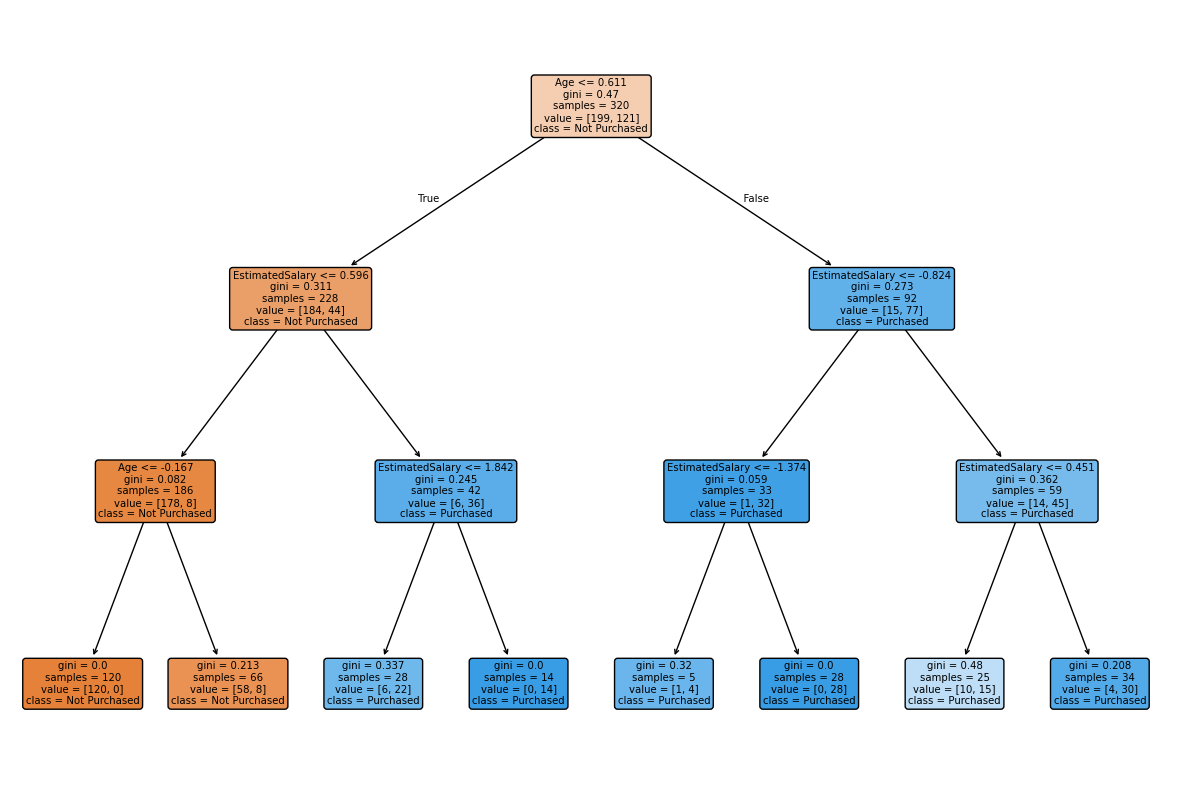

In [24]:
plot_decision_tree(clf, ['Age', 'EstimatedSalary'], ['Not Purchased', 'Purchased'])

In [33]:
import graphviz

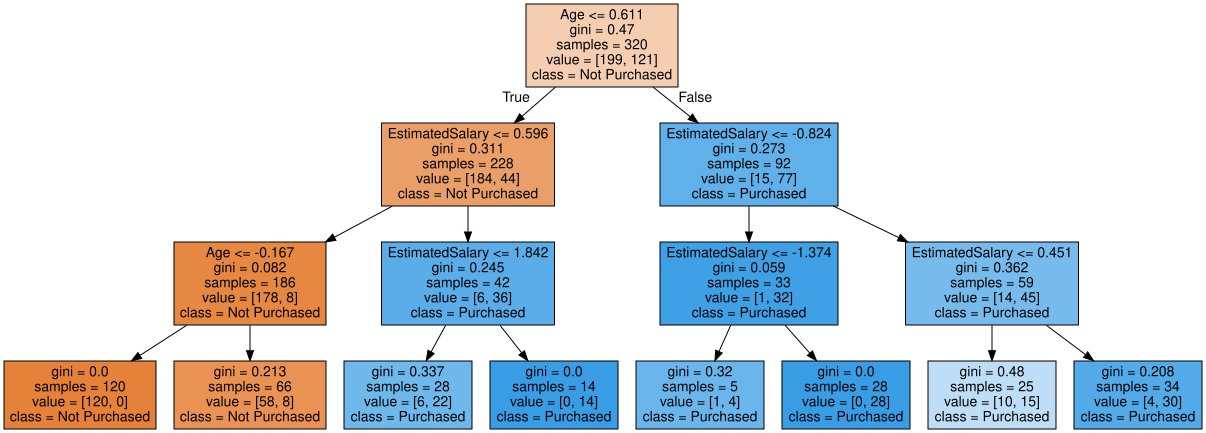

In [35]:
dot_data = tree.export_graphviz(clf, out_file=None,
                                feature_names=['Age', 'EstimatedSalary'],
                                class_names=['Not Purchased', 'Purchased'],
                                filled=True)

graph = graphviz.Source(dot_data, format="png")
graph

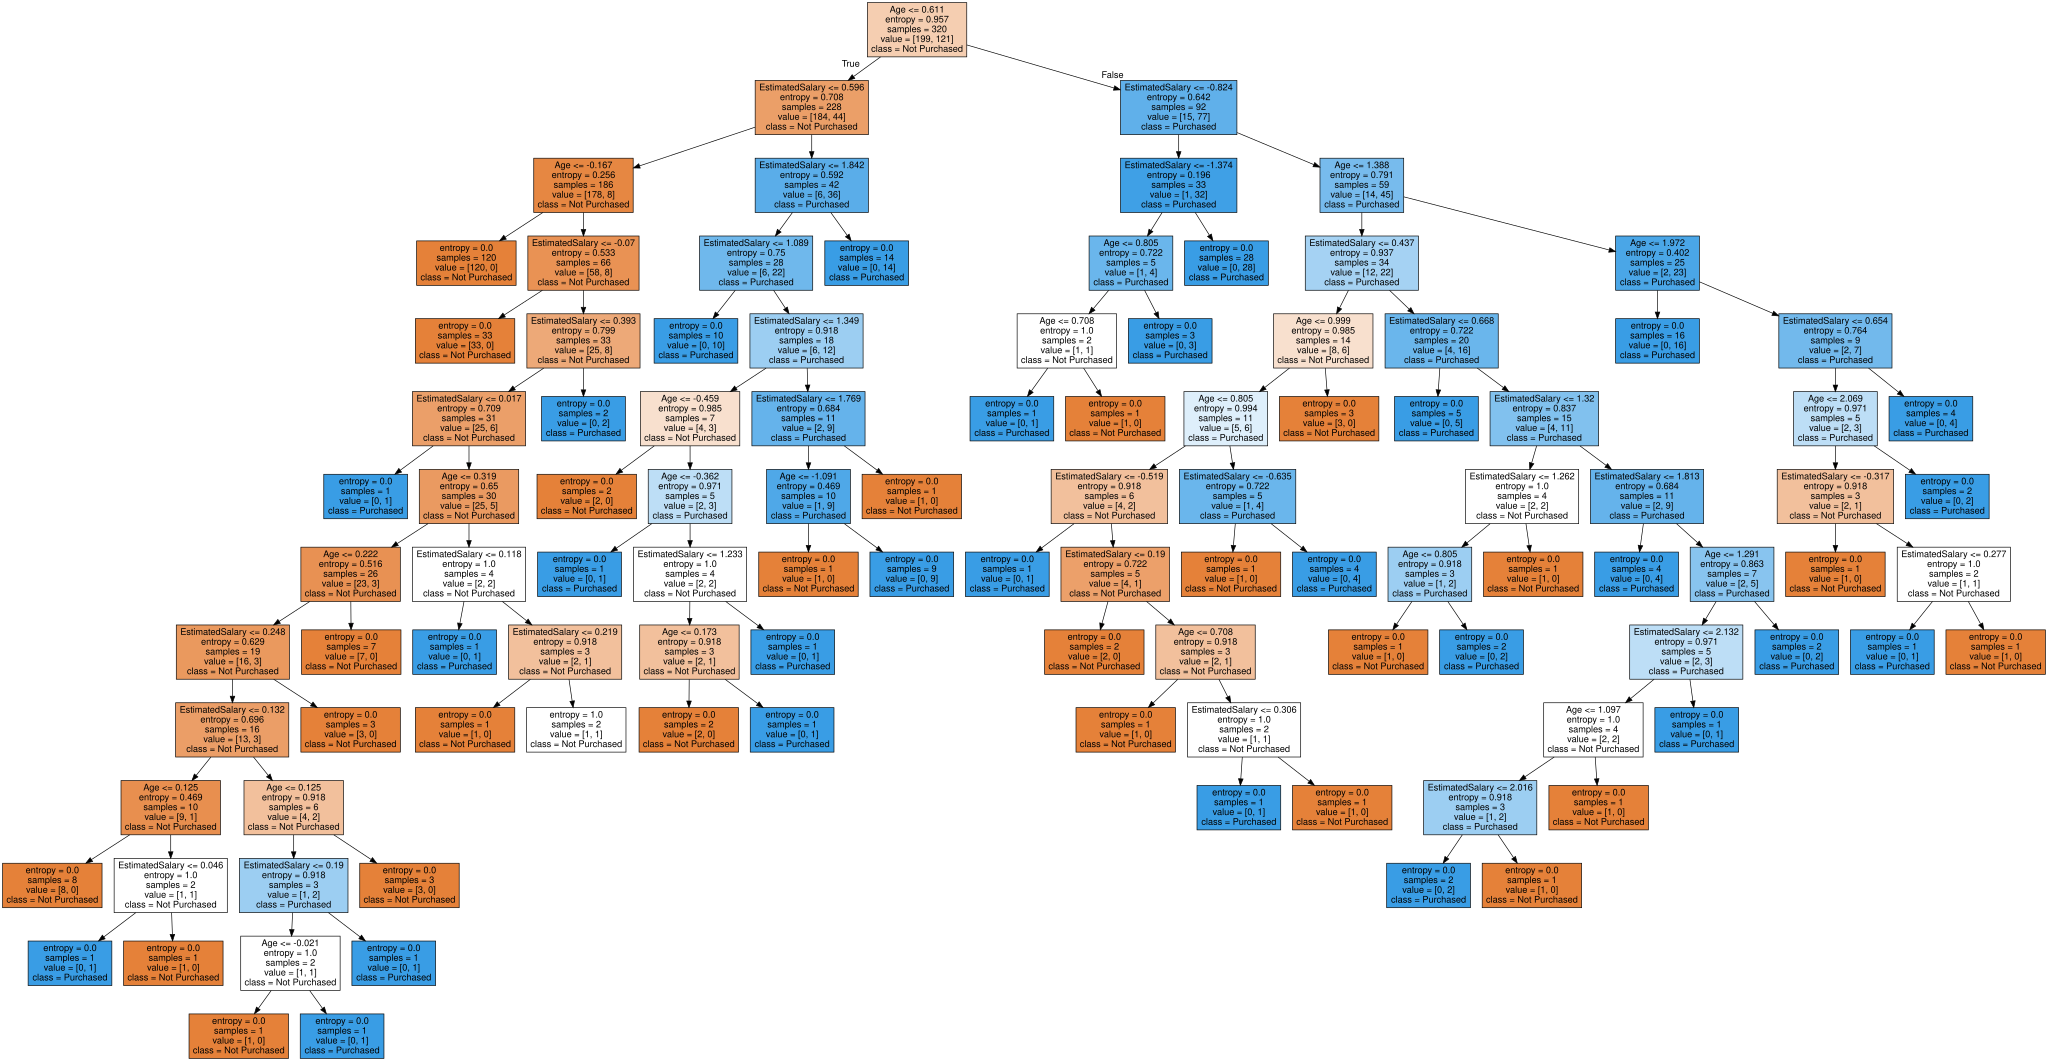

In [36]:
dot_data = tree.export_graphviz(classifier_dt, out_file=None,
                                feature_names=['Age', 'EstimatedSalary'],
                                class_names=['Not Purchased', 'Purchased'],
                                filled=True)

graph = graphviz.Source(dot_data, format="png")
graph